In [1]:
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import date,timedelta
import pyfolio as pf
%matplotlib inline

if '_LOCAL_PATH_LOADED' not in locals():
    %load_ext autoreload
    %autoreload 2
    import os
    import sys
    module_root='C:/Users/orduk/PycharmProjects/backtest'
    module_path = os.path.abspath(module_root) # or the path to your source code
    sys.path.insert(0, module_path)
    print(f'Added {module_root} to PYTHONPATH')
    _LOCAL_PATH_LOADED=True


Added C:/Users/orduk/PycharmProjects/backtest to PYTHONPATH


C:\Users\orduk\anaconda3\envs\aocapital\lib\site-packages\pyfolio\pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


In [2]:
from strategy.ensemble import getAllSignals

In [3]:
signals = getAllSignals(date(2007,1,1),date(2023,12,31))
MEASURES = sorted(['c2c', 'o2c', 'c2cdn', 'o2cdn', 'c2cbn','o2cbn', 'c2csn', 'o2csn'])

#Drop bad prices - mostly from news referring to GOOG vs GOOGL, BRKB vs -B etc. 
signals.replace([np.inf, -np.inf], np.nan, inplace=True)
signals.dropna(subset=MEASURES,inplace=True) #Mostly news referring to GOOG vs GOOGL, BRKB vs -B etc. 

signals.set_index('date',inplace=True, drop=False)
signals['prediction_tstat'] = signals.prediction.abs()/signals.predicted_se #Certainty of ARIMA prediction - unsigned
#popuate with -1,0,1 direction columns for each signal 
signals['arima_direction']=0
signals.loc[signals.prediction>0,'arima_direction']=1
signals.loc[signals.prediction<0,'arima_direction']=-1

signals['avel_direction']=0
signals.loc[signals.signal<0,'avel_direction']=1
signals.loc[signals.signal>0,'avel_direction']=-1

signals['news_direction']=0
signals.loc[signals.Sentiment>0,'news_direction']=1
signals.loc[signals.Sentiment<0,'news_direction']=-1

In [5]:
#Exclude outliers - most likely bad data
LIMIT = .5 #( 50% up/down c2c or o2c return (
mask = None
for measure in MEASURES:
    cond = signals[measure].abs() < LIMIT
    mask = cond if mask is None else mask & cond
signalsOutliers = signals[~mask]
signalsGood = signals[mask]
(signalsOutliers.shape,signalsGood.shape)
signals = signalsGood

In [7]:
aggs = { x: 'mean'  for x in MEASURES }
aggs['sym'] = 'count'
def displayStats(gbcols, signals=signals):
    print(f'Aggregating by {gbcols}')
    gbcols = gbcols or pd.Series(data=['TOTAL']*len(signals),index=signals.index)
    gb = signals.groupby(gbcols)
    stats = gb.agg(aggs).reset_index(drop=False).rename(columns={'sym':'trades'})
    stats['trade_pct'] = 100*stats.trades / stats.trades.sum()
    #BPS
    for m in MEASURES:
        stats[m]=10000*stats[m]
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(stats)

displayStats([])
#displayStats([],signalsOutliers)

for x in ['arima_direction','avel_direction','news_direction']:
    displayStats([x])
    
displayStats(['arima_direction','avel_direction','news_direction'])


Aggregating by []


,index,c2c,c2cbn,c2cdn,c2csn,o2c,o2cbn,o2cdn,o2csn,trades,trade_pct
0,TOTAL,2.23,-3.59,-2.27,-3.35,-2.26,-4.53,-3.99,-3.28,4996546,100.00


Aggregating by ['arima_direction']


,arima_direction,c2c,c2cbn,c2cdn,c2csn,o2c,o2cbn,o2cdn,o2csn,trades,trade_pct
0,-1,0.14,-7.70,-5.65,-6.09,-2.84,-5.41,-4.39,-3.11,573915,11.49
1,0,1.25,-4.22,-3.00,-4.11,-3.02,-5.30,-4.78,-4.12,3835023,76.75
2,1,10.61,4.49,5.83,4.24,3.24,1.34,1.58,2.08,587608,11.76


Aggregating by ['avel_direction']


,avel_direction,c2c,c2cbn,c2cdn,c2csn,o2c,o2cbn,o2cdn,o2csn,trades,trade_pct
0,-1,-0.76,-10.19,-6.72,-11.57,-3.14,-6.87,-5.51,-6.93,1146583,22.95
1,0,1.07,-4.79,-3.45,-4.76,-3.53,-5.61,-5.11,-4.58,2715495,54.35
2,1,8.02,5.95,5.05,8.31,1.67,0.41,0.24,3.53,1134468,22.71


Aggregating by ['news_direction']


,news_direction,c2c,c2cbn,c2cdn,c2csn,o2c,o2cbn,o2cdn,o2csn,trades,trade_pct
0,-1,-18.89,-24.66,-23.38,-25.05,-8.38,-11.07,-10.64,-10.44,1272416,25.47
1,0,4.61,-1.77,-0.29,-1.24,-0.35,-2.82,-2.17,-1.33,2684036,53.72
2,1,21.90,17.48,18.45,17.75,0.30,-0.97,-0.54,0.47,1040094,20.82


Aggregating by ['arima_direction', 'avel_direction', 'news_direction']


,arima_direction,avel_direction,news_direction,c2c,c2cbn,c2cdn,c2csn,o2c,o2cbn,o2cdn,o2csn,trades,trade_pct
0,-1,-1,-1,-10.24,-28.05,-24.29,-30.46,-0.92,-8.99,-7.31,-10.05,6706,0.13
1,-1,-1,0,-14.89,-23.63,-20.85,-24.68,-12.35,-14.89,-13.70,-14.01,85973,1.72
2,-1,-1,1,-0.88,-7.93,-4.28,-4.38,-7.45,-8.78,-7.01,-4.21,8549,0.17
3,-1,0,-1,-9.81,-18.54,-16.34,-18.53,-2.00,-4.64,-4.03,-3.93,28697,0.57
4,-1,0,0,3.79,-4.59,-2.27,-2.86,-0.57,-3.16,-2.13,-1.07,387152,7.75
5,-1,0,1,15.99,10.52,12.19,17.51,0.31,-0.15,0.57,5.79,20202,0.40
6,-1,1,-1,3.02,0.22,-2.72,-0.21,6.01,1.86,1.54,3.85,3760,0.08
7,-1,1,0,-2.68,-1.69,-4.70,3.27,-7.34,-9.92,-9.11,-2.73,30941,0.62
8,-1,1,1,-1.82,9.94,3.86,27.42,-12.57,-14.23,-13.45,2.42,1935,0.04
9,0,-1,-1,-11.80,-23.12,-18.86,-25.08,-1.10,-7.48,-5.63,-8.11,79111,1.58


In [6]:
from quant.symreturns import SymReturns
benchmarkReturns = SymReturns().getReturns(signals.index.min(),signals.index.max(),['SPY'])
benchmarkReturns.index = pd.to_datetime(benchmarkReturns.date)

            {[syms;sd;ed]
                (select sym, date, beta, etf, etf_beta, c2c, o2c, c2cdn, o2cdn, c2cbn, o2cbn, c2csn, o2csn, `float$year, asof_date from sym_returns where year >= `year$sd, year <=`year$ed,date>=sd,date<=ed,sym in `$syms)
                lj 2! select date,sym,adjusted_close,close,`float$volume from eodhd_price where year >= `year$sd, year <=`year$ed,date>=sd,date<=ed,sym in `$syms
            }
        


In [14]:
def drets(mask,positions,MEASURES=MEASURES):
    ''' daily returns '''
    trades = signals[ mask ][MEASURES].mul(positions[mask],axis=0)
    return trades.groupby(trades.index).mean()

def print_tearsheet( stype, positions = None, measure='o2cbn' ):
    positions = signals[f'{stype}_direction'] if positions is None else positions
    sdrets = drets(positions != 0, positions)
    m,s = sdrets[measure].mean(), sdrets[measure].std()
    print(f'{stype} daily alpha = {10000*m:.2f} bps std = {10000*s:.2f} bps daily Sharpe {(m/s):.2f} annualized {np.sqrt(252)*m/s:.2f}')
    pyfreturns = pd.Series(index = pd.to_datetime(sdrets.index),data = sdrets.o2cbn)
    #pf.create_full_tear_sheet(returns = pyfreturns,benchmark_rets=benchmarkReturns.o2cbn)
    pf.create_simple_tear_sheet(returns=pyfreturns,benchmark_rets = benchmarkReturns.o2cbn)
    pf.create_returns_tear_sheet(returns=pyfreturns,benchmark_rets = benchmarkReturns.o2cbn)


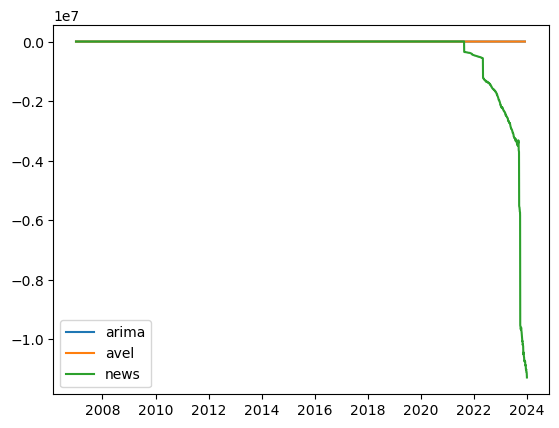

In [38]:
arima_prets = (1+drets( signals['arima_direction']!=0, signals['arima_direction'])['c2cbn']).cumprod()
avel_prets = (1+drets( signals['avel_direction']!=0, signals['avel_direction'])['c2cbn']).cumprod()
news_prets = (1+drets( signals['news_direction']!=0, signals['news_direction'])['c2cbn']).cumprod()
plt.plot(arima_prets,label='arima')
plt.plot(avel_prets,label='avel')
plt.plot(news_prets,label='news')
plt.legend()

In [57]:
news_signals = drets( signals['news_direction']!=0, signals['news_direction'])
bad_date = news_signals.iloc[news_signals.c2c.argmin()].name
bad_date
bad_data = signals[(signals.date==bad_date) & (signals.news_direction != 0)]
bad_data[bad_data.c2c.abs()>0.3]

,sym,date,target,prediction,predicted_se,model_order,modelP,modelQ,signal,oualpha,...,c2cdn,o2cdn,c2cbn,o2cbn,c2csn,o2csn,prediction_tstat,arima_direction,avel_direction,news_direction
date,,,,,,,,,,,,,,,,,,,,,
2021-08-17,HLBZ,2021-08-17,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,87271.734375,-0.288439,87271.726562,-0.288892,87271.726562,-0.288633,NaN,0,0,-1


In [16]:
#print_tearsheet('arima', signals['arima_direction'])

In [17]:
#print_tearsheet('avel', signals['avel_direction'])

In [18]:
#print_tearsheet('news', signals['news_direction'])

In [19]:
#consensus = signals.arima_direction.where((signals.arima_direction==signals.news_direction) & (signals.avel_direction==signals.news_direction)).fillna(0)
#print_tearsheet('consensus', consensus)

majority daily alpha = 4.60 bps std = 25.89 bps daily Sharpe 0.18 annualized 2.82


C:\Users\orduk\Anaconda3\envs\aocapital\lib\site-packages\pyfolio\plotting.py:666: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '12.18%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2007-01-03
End date,2023-12-29
Total months,203
,Backtest
Annual return,12.18%
Cumulative returns,603.68%
Annual volatility,4.109%
Sharpe ratio,2.82
Calmar ratio,2.46
Stability,0.98
Max drawdown,-4.947%


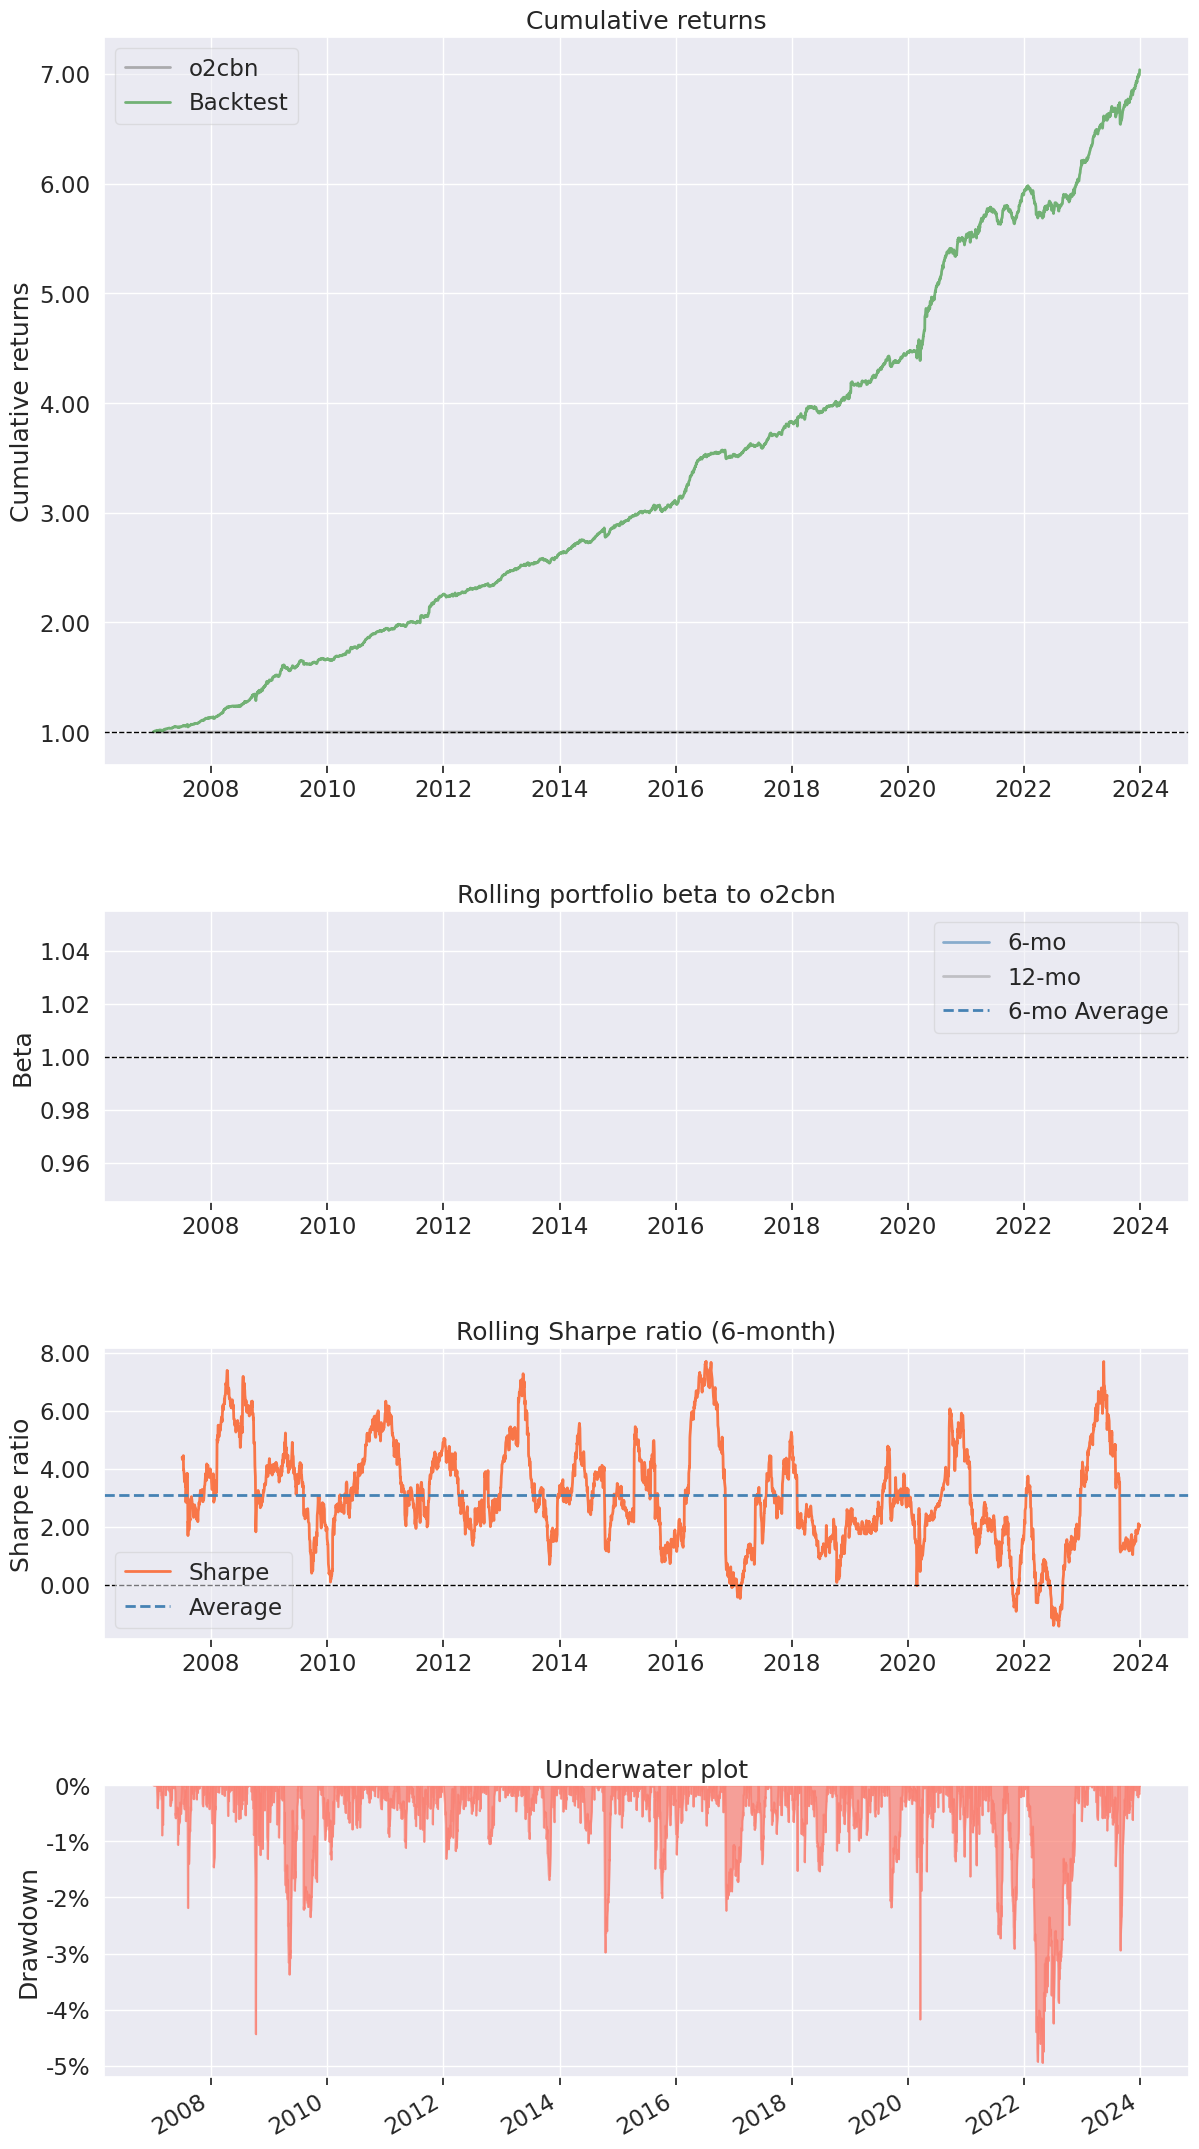

In [21]:
majority = np.sign(signals.arima_direction+signals.avel_direction+signals.news_direction)
print_tearsheet('majority', majority)

In [15]:
FEATURES="prediction prediction_tstat beta volatility ADVD oualpha ougamma oubeta signal Sentiment".split()
TARGET = 'o2cbn'
sim_ba = sim[(sim.arima_pos != 0) & (sim.arima_pos == sim.avel_pos) ].copy()
sim_ba['RETURN'] = sim_ba.arima_pos*sim_ba[TARGET]

In [19]:
q = list(np.arange(0,1.,.1))
labels = [str(int(10*s)) for s in q]
for c in  FEATURES:
    if c != 'Sentiment':
        sim_ba[f'{c}_q']= pd.qcut( sim_ba[c],q+[1],retbins=False,labels=labels)
    else:
        sim_ba['Sentiment_q']=np.sign(sim_ba.Sentiment)
        

In [20]:
for col in  FEATURES:
    qCol = col+'_q'
    stats=sim_ba.groupby(qCol).agg({'RETURN':[np.mean,np.std,min,max],col: [np.min,np.max],
                                         'RETURN': [np.mean]})
    with pd.option_context('display.float_format', '{:,.4f}'.format):
        print(f'{col} decile stats\n {stats}\n')

prediction decile stats
              RETURN prediction        
               mean        min     max
prediction_q                          
0            0.0043    -1.5729 -0.0143
1            0.0013    -0.0143 -0.0085
2            0.0006    -0.0085 -0.0054
3            0.0007    -0.0054 -0.0031
4            0.0001    -0.0031 -0.0002
5            0.0001    -0.0002  0.0029
6            0.0005     0.0029  0.0050
7            0.0008     0.0050  0.0078
8            0.0011     0.0078  0.0128
9            0.0021     0.0128  1.7311

prediction_tstat decile stats
                    RETURN prediction_tstat        
                     mean              min     max
prediction_tstat_q                                
0                  0.0001           0.0000  0.1041
1                  0.0004           0.1041  0.1740
2                  0.0007           0.1740  0.2307
3                  0.0007           0.2307  0.2831
4                  0.0010           0.2831  0.3371
5                  0.0010   

In [21]:
hi_conviction = sim_ba[ (sim_ba.signal_q.astype(int).isin([0,1,2,3,6,7,8,9])) & \
    ( sim_ba.prediction_tstat_q.astype(int) >= 4 ) ]
    #( sim_ba.prediction_q.astype(int).isin([0,1,2,7,8,9]) )]

DAILY RETURN 11bps SDEV 87bps
DAILY SHARP 0.12 - ANNUALIZED 1.94
YEARLY AVG 31.71pct SHARP 1.19 
MONTHLY AVG 2.24pct SHARP 0.56 ANNUALIZED 1.92
NONEWS DAILY RETURN 13bps SDEV 93bps
NONEWS DAILY SHARP 0.14 - ANNUALIZED 2.14
NONEWS YEARLY AVG 38.40pct SHARP 1.25 
NONEWS MONTHLY AVG 2.64pct SHARP 0.62 ANNUALIZED 2.14


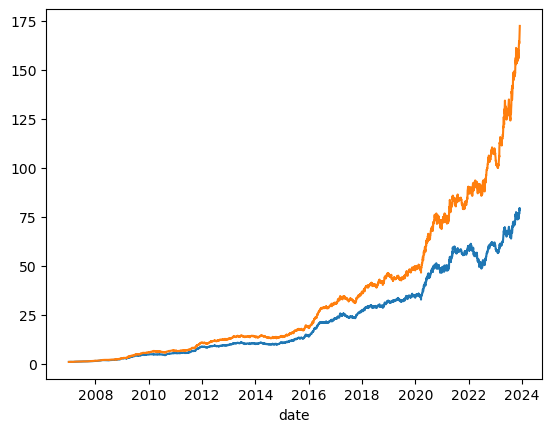

In [42]:
#TEMP
#hi_conviction = hi_conviction[hi_conviction.date<date(2013,1,1)]
daily = hi_conviction['RETURN'].groupby(hi_conviction.date).mean()
print(f'DAILY RETURN {10000*daily.mean():.0f}bps SDEV {10000*daily.std():.0f}bps')
print(f'DAILY SHARP {(daily.mean()/daily.std()):.2f} - ANNUALIZED {np.sqrt(252)*(daily.mean()/daily.std()):.2f}')

df = daily.reset_index()
df['year'] = df.date.apply(lambda x: x.year)
df['month'] = df.date.apply(lambda x: x.month)
df['CUMRETURN'] = 1+df['RETURN']

yearly = (1+df['RETURN']).groupby(df.year).prod()
monthly = (1+df['RETURN']).groupby([df.year,df.month]).prod()
print(f'YEARLY AVG {100*(yearly.mean()-1):.2f}pct SHARP {((yearly.mean()-1)/yearly.std()):.2f} ')
print(f'MONTHLY AVG {100*(monthly.mean()-1):.2f}pct SHARP {((monthly.mean()-1)/monthly.std()):.2f} ANNUALIZED {np.sqrt(12)*((monthly.mean()-1)/monthly.std()):.2f}')


(1+daily).cumprod().plot()
badnews = hi_conviction[hi_conviction.Sentiment_q<0]
goodnews = hi_conviction[hi_conviction.Sentiment_q>0]
nonews = hi_conviction[hi_conviction.Sentiment_q==0]

##(1+badnews['RETURN']).groupby(badnews.date).mean().cumprod().plot(title='badnews')
#1+goodnews['RETURN']).groupby(goodnews.date).mean().cumprod().plot(legend=True)
nn_daily = nonews['RETURN'].groupby(nonews.date).mean()
df = nn_daily.reset_index()
df['year'] = df.date.apply(lambda x: x.year)
df['month'] = df.date.apply(lambda x: x.month)
nn_yearly = (1+df['RETURN']).groupby(df.year).prod()
nn_monthly = (1+df['RETURN']).groupby([df.year,df.month]).prod()

(1+nonews['RETURN']).groupby(nonews.date).mean().cumprod().plot()
print(f'NONEWS DAILY RETURN {10000*nn_daily.mean():.0f}bps SDEV {10000*nn_daily.std():.0f}bps')
print(f'NONEWS DAILY SHARP {(nn_daily.mean()/nn_daily.std()):.2f} - ANNUALIZED {np.sqrt(252)*(nn_daily.mean()/nn_daily.std()):.2f}')
print(f'NONEWS YEARLY AVG {100*(nn_yearly.mean()-1):.2f}pct SHARP {((nn_yearly.mean()-1)/nn_yearly.std()):.2f} ')

print(f'NONEWS MONTHLY AVG {100*(nn_monthly.mean()-1):.2f}pct SHARP {((nn_monthly.mean()-1)/nn_monthly.std()):.2f} ANNUALIZED {np.sqrt(12)*((nn_monthly.mean()-1)/nn_monthly.std()):.2f}')



In [235]:
from IPython.display import display
bysym=hi_conviction.groupby('sym').agg({'RETURN':['mean','std','count'],'date':['min','max']})
bysym.columns=['avg','sdev','trades','firstDate','lastDate']
bysym['score'] = bysym.trades*bysym.avg
bysym.sort_values('score',inplace=True)
with pd.option_context('display.max_rows',6):
    display(bysym)

,avg,sdev,trades,firstDate,lastDate,score
sym,,,,,,
BEE,-0.048095,0.080879,28,2008-11-03,2014-03-14,-1.346655
BPOP,-0.020434,0.037929,46,2007-07-19,2021-06-18,-0.939981
WNC,-0.015925,0.100675,51,2007-06-04,2020-05-29,-0.812157
...,...,...,...,...,...,...
FSP,0.026379,0.065483,88,2008-03-03,2013-05-31,2.321348
WTBA,0.015814,0.053016,182,2008-09-17,2020-09-22,2.878124
LKFN,0.018718,0.041952,158,2007-02-22,2015-01-23,2.957404


<AxesSubplot:>

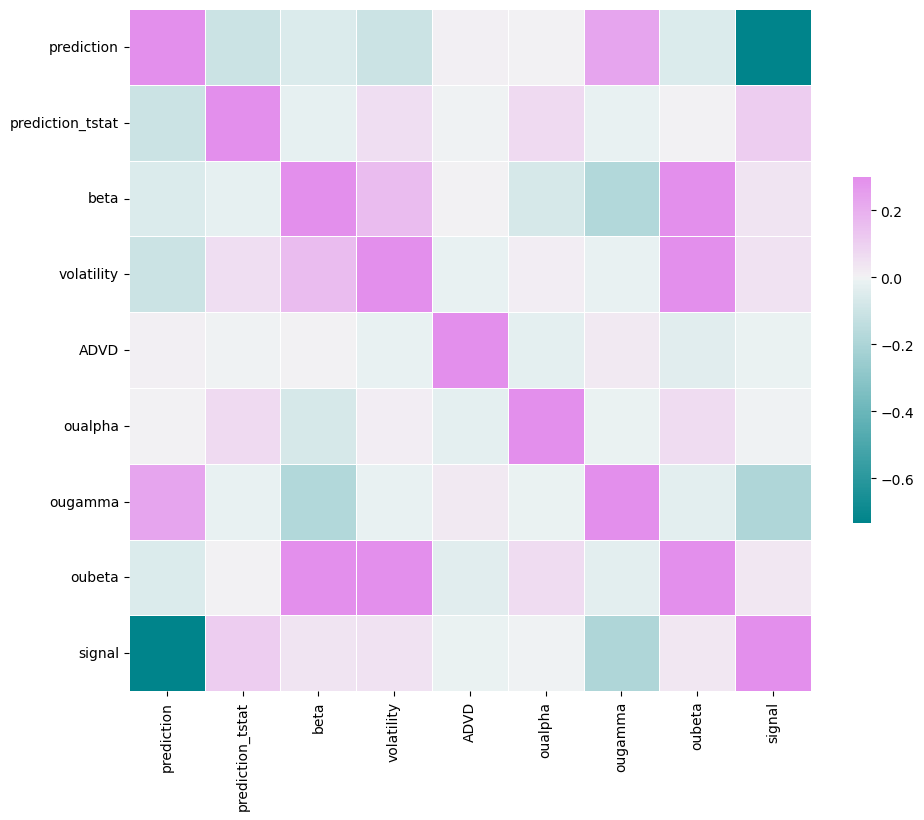

In [237]:
#Feature correlations
featdf = hi_conviction[FEATURES]
corr = featdf.corr()
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(200, 300, s=100, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=None, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})


In [244]:
#Feature importance using XGBoost
from xgboost import XGBRegressor
X = hi_conviction[FEATURES]
Y = hi_conviction['RETURN']
xgr = XGBRegressor(n_estimators=100,max_depth=4)
#pipe = make_pipeline(ct,rf)   
pipe = make_pipeline(xgr)
pipe.fit(X,Y)
#rf.fit(X,Y)
from sklearn.metrics import r2_score
print(f'R2 score {r2_score(Y, pipe.predict(X))} ') 
fi_df = pd.DataFrame({'feature':FEATURES,'importance':xgr.feature_importances_})
fi_df.sort_values('importance', ascending=False,inplace=True)
display(fi_df)

R2 score 0.2847039422578914 


,feature,importance
5,oualpha,0.119663
4,ADVD,0.117974
2,beta,0.117722
7,oubeta,0.114374
3,volatility,0.111823
1,prediction_tstat,0.109367
8,signal,0.109046
6,ougamma,0.105754
0,prediction,0.094277


In [247]:
#Feature importance using RandomForest
X = hi_conviction[FEATURES]
Y = hi_conviction['RETURN']
rf = RandomForestRegressor(n_estimators=100,max_depth=4,verbose=True)
pipe = make_pipeline(rf)
pipe.fit(X,Y)
from sklearn.metrics import r2_score
print(f'R2 score {r2_score(Y, pipe.predict(X))} ') 
fi_df = pd.DataFrame({'feature':FEATURES,'importance':rf.feature_importances_})
fi_df.sort_values('importance', ascending=False,inplace=True)
display(fi_df)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   28.8s


R2 score 0.013072641267905416 


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


,feature,importance
0,prediction,0.324452
8,signal,0.163653
1,prediction_tstat,0.114614
7,oubeta,0.093450
2,beta,0.088110
4,ADVD,0.071515
3,volatility,0.058033
6,ougamma,0.054602
5,oualpha,0.031571
